In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
df_selected = pd.read_csv('/Users/yuxianggao/Desktop/df_selected.csv')

In [4]:
df_selected.columns

Index(['APARTMENTS_MEDI', 'TOTALAREA_MODE', 'REG_CITY_NOT_WORK_CITY',
       'ELEVATORS_MODE', 'EXT_SOURCE_3', 'REGION_RATING_CLIENT_W_CITY',
       'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'FLOORSMAX_MEDI', 'EXT_SOURCE_1',
       'AMT_GOODS_PRICE', 'LIVINGAREA_MODE', 'DAYS_LAST_PHONE_CHANGE',
       'APARTMENTS_MODE', 'NAME_INCOME_TYPE', 'ELEVATORS_MEDI', 'DAYS_BIRTH',
       'REGION_POPULATION_RELATIVE', 'OCCUPATION_TYPE', 'APARTMENTS_AVG',
       'ORGANIZATION_TYPE', 'CODE_GENDER', 'LIVINGAREA_MEDI', 'FLOORSMAX_AVG',
       'FLAG_EMP_PHONE', 'LIVINGAREA_AVG', 'NAME_EDUCATION_TYPE',
       'EXT_SOURCE_2', 'ELEVATORS_AVG', 'FLOORSMAX_MODE',
       'REGION_RATING_CLIENT', 'AMT_CREDIT', 'TARGET'],
      dtype='object')

In [5]:
df_selected = df_selected[(df_selected['DAYS_EMPLOYED'] != 365243) & (~df_selected.isin(['XNA']).any(axis=1))]
df_selected.shape

(252133, 33)

In [6]:
def impute_missing_values(df):
    """Impute missing values in numerical and categorical columns."""
    df = df.copy()  # Avoid modifying the original DataFrame

    # Impute numerical columns with the mean
    for col in df.select_dtypes(include=['int64', 'float64']).columns:
        if df[col].isnull().all():
            # If the column is entirely NaN, replace with 0 or another placeholder
            df[col].fillna(0, inplace=True)
        else:
            df[col].fillna(df[col].mean(), inplace=True)

    # Impute categorical columns with the most frequent value (mode)
    for col in df.select_dtypes(include=['object', 'category']).columns:
        if df[col].isnull().all():
            # If the column is entirely NaN, replace with a placeholder (e.g., 'Missing')
            df[col].fillna('Missing', inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)
    
    return df
def preprocess_data(df):
    """Preprocess the dataset: Imputation and One-Hot Encoding."""
    # Impute missing values
    df_imputed = impute_missing_values(df)
    
    # Perform one-hot encoding
    df_encoded = pd.get_dummies(df_imputed, drop_first=True).astype(int)  # Avoid multicollinearity with drop_first
    return df_encoded

In [7]:
df_process = preprocess_data(df_selected)

/var/folders/9j/g70s104d0rx3nbz653lx2q7r0000gn/T/ipykernel_15296/104042065.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/var/folders/9j/g70s104d0rx3nbz653lx2q7r0000gn/T/ipykernel_15296/104042065.py:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [8]:
features = df_process.drop(columns=['TARGET'])  # Exclude the target column
target = df_process['TARGET']  # Keep the target column

# Scale only the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

# Convert back to DataFrame and add the target column
scaled_df = pd.DataFrame(scaled_features, columns=features.columns, index=df_process.index)
scaled_df['TARGET'] = target  # Add the target column back


In [9]:
X = scaled_df.drop(columns=['TARGET'])
y = scaled_df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.metrics import classification_report, confusion_matrix

### Logistics Regression

In [10]:
from sklearn.linear_model import LogisticRegressionCV

In [12]:
log_model = LogisticRegressionCV(random_state=42, cv=5,penalty='l2')
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

print('AUC: {:.2f}'.format(roc_auc_score(y_test, y_pred_proba)))
print('Accuracy: {:.2f}'.format(accuracy_score(y_test, y_pred)))
print('Recall: {:.2f}'.format(recall_score(y_test, y_pred)))

AUC: 0.66
Accuracy: 0.91
Recall: 0.00


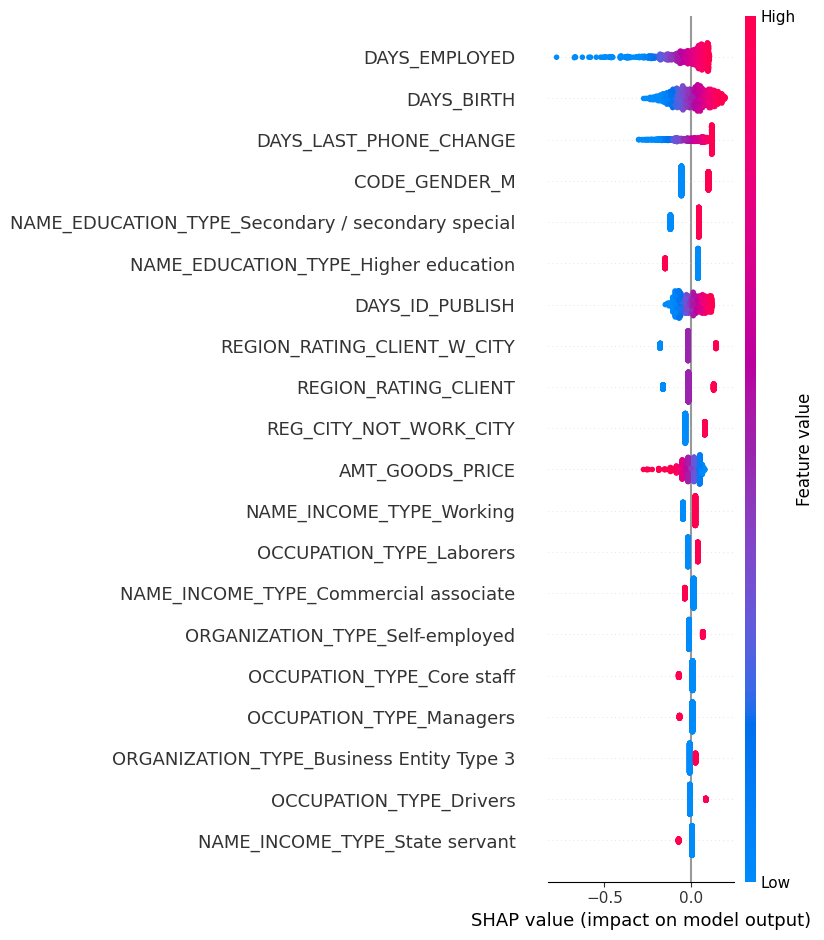

In [ ]:
import shap

# Create SHAP explainer for Logistic Regression
feature_names = X_train.columns.tolist()

explainer = shap.LinearExplainer(log_model, X_train)

# # Compute SHAP values for the test set
# shap_values = explainer(X_test)

# # Summary plot for feature importance
# shap.summary_plot(shap_values.values, X_test, feature_names=feature_names, max_display=20)

# Sample 1000 rows from the test set
X_test_sample = shap.sample(X_test, 1000)

# Compute SHAP values on the smaller dataset
shap_values_sample = explainer(X_test_sample)

# Summary plot
shap.summary_plot(shap_values_sample.values, X_test_sample, feature_names=feature_names, max_display=20)


### Resampling

In [11]:
from sklearn.utils import resample

# Downsample majority class
majority = scaled_df[scaled_df['TARGET'] == 0]
minority = scaled_df[scaled_df['TARGET'] == 1]

majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=42)
balanced_df = pd.concat([majority_downsampled, minority])


In [12]:
X = balanced_df.drop(columns=['TARGET'])
y = balanced_df['TARGET']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
log_model = LogisticRegressionCV(random_state=42, cv=5,penalty='l2')
log_model.fit(X_train, y_train)

y_pred = log_model.predict(X_test)
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

print('AUC: {:.5f}'.format(roc_auc_score(y_test, y_pred_proba)))
print('Accuracy: {:.5f}'.format(accuracy_score(y_test, y_pred)))
print('Recall: {:.5f}'.format(recall_score(y_test, y_pred)))

AUC: 0.66490
Accuracy: 0.61782
Recall: 0.64532


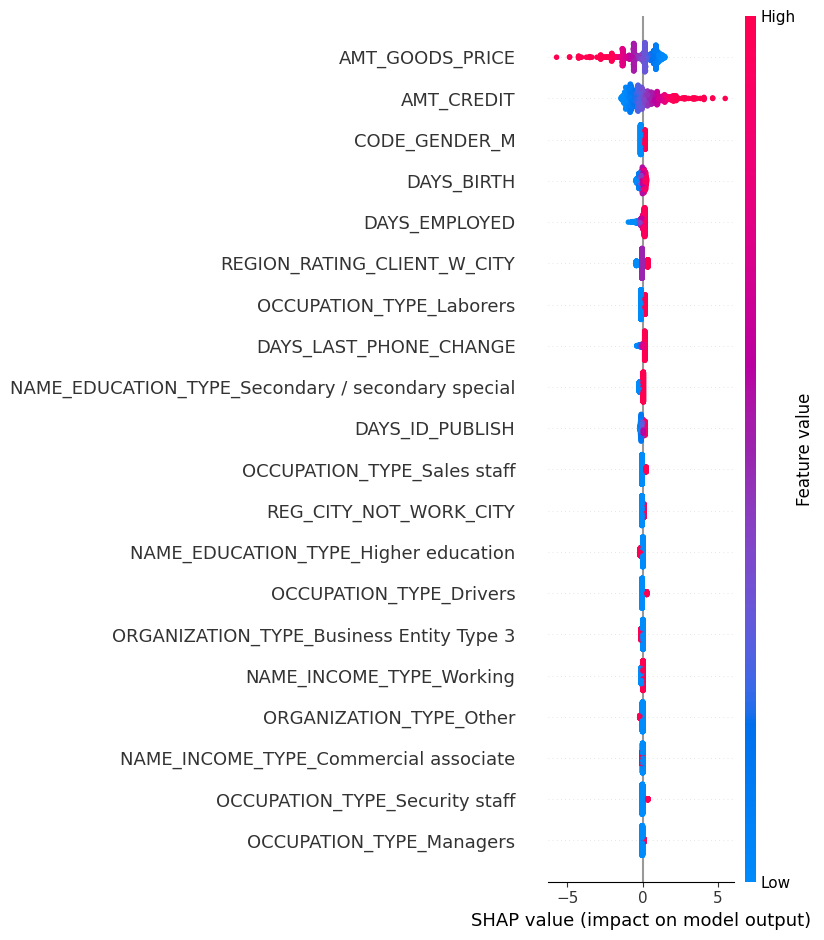

In [14]:
import shap

# Create SHAP explainer for Logistic Regression
feature_names = X_train.columns.tolist()

explainer = shap.LinearExplainer(log_model, X_train)

# # Compute SHAP values for the test set
# shap_values = explainer(X_test)

# # Summary plot for feature importance
# shap.summary_plot(shap_values.values, X_test, feature_names=feature_names, max_display=20)

# Sample 1000 rows from the test set
X_test_sample = shap.sample(X_test, 1000)

# Compute SHAP values on the smaller dataset
shap_values_sample = explainer(X_test_sample)

# Summary plot
shap.summary_plot(shap_values_sample.values, X_test_sample, feature_names=feature_names, max_display=20)


### XGboost

In [16]:
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import confusion_matrix

In [ ]:
xgb_model = XGBClassifier(random_state=42, n_jobs=-1, eval_metric='logloss', early_stopping_rounds=10)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print('AUC: {:.5f}'.format(roc_auc_score(y_test, y_pred_proba)))
print('Accuracy: {:.5f}'.format(accuracy_score(y_test, y_pred)))
print('Recall: {:.5f}'.format(recall_score(y_test, y_pred)))

### MLP

In [1]:
mlp = MLPClassifier(alpha=1, early_stopping=True, hidden_layer_sizes=(50,),random_state=42)
mlp.fit(X_train, y_train)

y_pred = mlp.predict(X_test)
y_pred_proba = mlp.predict_proba(X_test)[:, 1]

print('AUC: {:.5f}'.format(roc_auc_score(y_test, y_pred_proba)))
print('Accuracy: {:.5f}'.format(accuracy_score(y_test, y_pred)))
print('Recall: {:.5f}'.format(recall_score(y_test, y_pred)))

NameError: name 'MLPClassifier' is not defined